# Note
- Utilizzare lo stesso font del testo della relazione

Relazione:
- Preambolo ispirato alla consegna (Es. Studiare l'errore di troncamento).
- Risultato
- Discussione del risultato
    - Aspettative
    - Discrepanze
    - Commenti


## Obiettivo

## 

# Librerie
Importo le librie necessarie per eseguire il programma.

In [111]:
using Pkg # Importo il package manager
Pkg.add("Plots") # Installo la libreria per i grafici
using Plots # Importo la libreria per i grafici
using Printf # Importo la libreria per la formattazione delle stringhe

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


# Funzioni

In [112]:
function g(x, n)
    """
    Calcola la somma parziale della serie di Taylor di eˣ fino al termine n-esimo.
    Args:
        x (Float64): Il punto in cui valutare la serie.
        n (Int): Il numero di termini da includere nella somma.
    Returns:
        Float64: La somma parziale della serie di Taylor.
    """
    s = 0.0
    for k in 0:n
        s += (x^k) / factorial(k)
    end
    return s
end

f(x) = exp(x) # Funzione esatta (esponenziale)

absolute_error(x, N) = Base.abs(f(x) - g(x, N)) # Errore assoluto

theoretical_error(x, N) = x^(N + 1) / factorial(N + 1) # Errore teorico

theoretical_error (generic function with 1 method)

# Dati

In [113]:
# Dati iniziali
x_values = range(0.0, 1.0, length=100)
n = [1, 2, 3, 4]

4-element Vector{Int64}:
 1
 2
 3
 4

In [114]:
# Stampa i risultati in una tabella
for N in n 
    for x in x_values
        err_abs = absolute_error(x, N)
        err_theo = theoretical_error(x, N)
        ratio = err_theo != 0 ? err_abs / err_theo : Inf
        @printf("%6.3f | %2d | %18.10e | %18.10e | %10.6f\n", x, N, err_abs, err_theo, ratio)
    end
end

 0.000 |  1 |   0.0000000000e+00 |   0.0000000000e+00 |        Inf
 0.010 |  1 |   5.1187405525e-05 |   5.1015202530e-05 |   1.003376
 0.020 |  1 |   2.0544192526e-04 |   2.0406081012e-04 |   1.006768
 0.030 |  1 |   4.6380991691e-04 |   4.5913682277e-04 |   1.010178
 0.040 |  1 |   8.2734836100e-04 |   8.1624324049e-04 |   1.013605
 0.051 |  1 |   1.2971249687e-03 |   1.2753800633e-03 |   1.017050
 0.061 |  1 |   1.8742182909e-03 |   1.8365472911e-03 |   1.020512
 0.071 |  1 |   2.5597178281e-03 |   2.4997449240e-03 |   1.023992
 0.081 |  1 |   3.3547241415e-03 |   3.2649729619e-03 |   1.027489
 0.091 |  1 |   4.2603489656e-03 |   4.1322314050e-03 |   1.031004
 0.101 |  1 |   5.2777153213e-03 |   5.1015202530e-03 |   1.034538
 0.111 |  1 |   6.4079576308e-03 |   6.1728395062e-03 |   1.038089
 0.121 |  1 |   7.6522218329e-03 |   7.3461891644e-03 |   1.041659
 0.131 |  1 |   9.0116655006e-03 |   8.6215692276e-03 |   1.045247
 0.141 |  1 |   1.0487457958e-02 |   9.9989796959e-03 |   1.04

# Plotto i dati

In [115]:
x_plot = range(0, 1, length=200) # Valori di x per il plot

0.0:0.005025125628140704:1.0

In [116]:
# Grafico 1: Funzione e approssimazioni
p1 = plot(x_plot, f.(x_plot), 
          linewidth=2, 
          color=:black, 
          label="f(x) = eˣ",
          xlabel="x",
          ylabel="y",
          title="Funzione e Approssimazioni di Taylor",
          legend=:topleft,
          grid=true)

colors = [:blue, :red, :green, :orange]
for (i, N) in enumerate([1, 2, 3, 4]) # Aggiungo le approssimazioni al grafico
    plot!(p1, x_plot, [g(x, N) for x in x_plot],
          linestyle=:dash,
          linewidth=1.5,
          color=colors[i],
          label="g_$N(x)")
end

In [117]:
# Grafico 2: Errore assoluto
p2 = plot(xlabel="x",
          ylabel="Errore assoluto |Δ|",
          title="Errore Assoluto (scala logaritmica)",
          legend=:topleft,
          yscale=:log10,
          grid=true)

for (i, N) in enumerate([1, 2, 3, 4]) # Aggiungo gli errori al grafico
    errors = [absolute_error(x, N) for x in x_plot]
    plot!(p2, x_plot, errors,
          linewidth=2,
          color=colors[i],
          label="N = $N")
end

In [ ]:
# Grafico 3: Confronto errore reale vs teorico
p3 = plot(xlabel="x",
          ylabel="Errore",
          title="Confronto Errori per N = 3",
          legend=:topleft,
          grid=true)

N = 3

# Calcolo gli errori
err_real = [absolute_error(x, N) for x in x_plot]
err_theo = [theoretical_error(x, N) for x in x_plot]

# Aggiungo gli errori al grafico
plot!(p3, x_plot, err_real,
      linewidth=2,
      color=:blue,
      label="Δ (reale)")
plot!(p3, x_plot, err_theo,
      linestyle=:dash,
      linewidth=2,
      color=:red,
      label="x^(N+1)/(N+1)!")

LoadError: LoadError: UndefVarError: `@f_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /Users/lorenzominuz/University/Terzo anno/Esperimentazioni di Fisica Computazionale/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:6

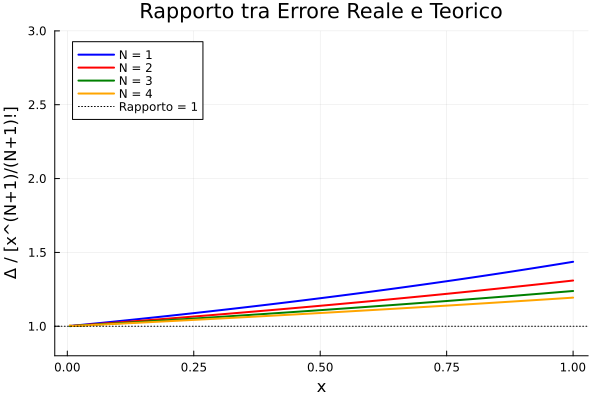

In [119]:
# Grafico 4: Rapporto errore reale / teorico
p4 = plot(xlabel="x",
          ylabel="Δ / [x^(N+1)/(N+1)!]",
          title="Rapporto tra Errore Reale e Teorico",
          legend=:topleft,
          grid=true,
          ylims=(0.8, 3))

x_plot_nonzero = collect(x_plot)[2:end]
for (i, N) in enumerate([1, 2, 3, 4])
    ratios = [absolute_error(x, N) / theoretical_error(x, N) for x in x_plot_nonzero]
    plot!(p4, x_plot_nonzero, ratios,
          linewidth=2,
          color=colors[i],
          label="N = $N")
end
hline!(p4, [1], linestyle=:dot, color=:black, linewidth=1, label="Rapporto = 1")


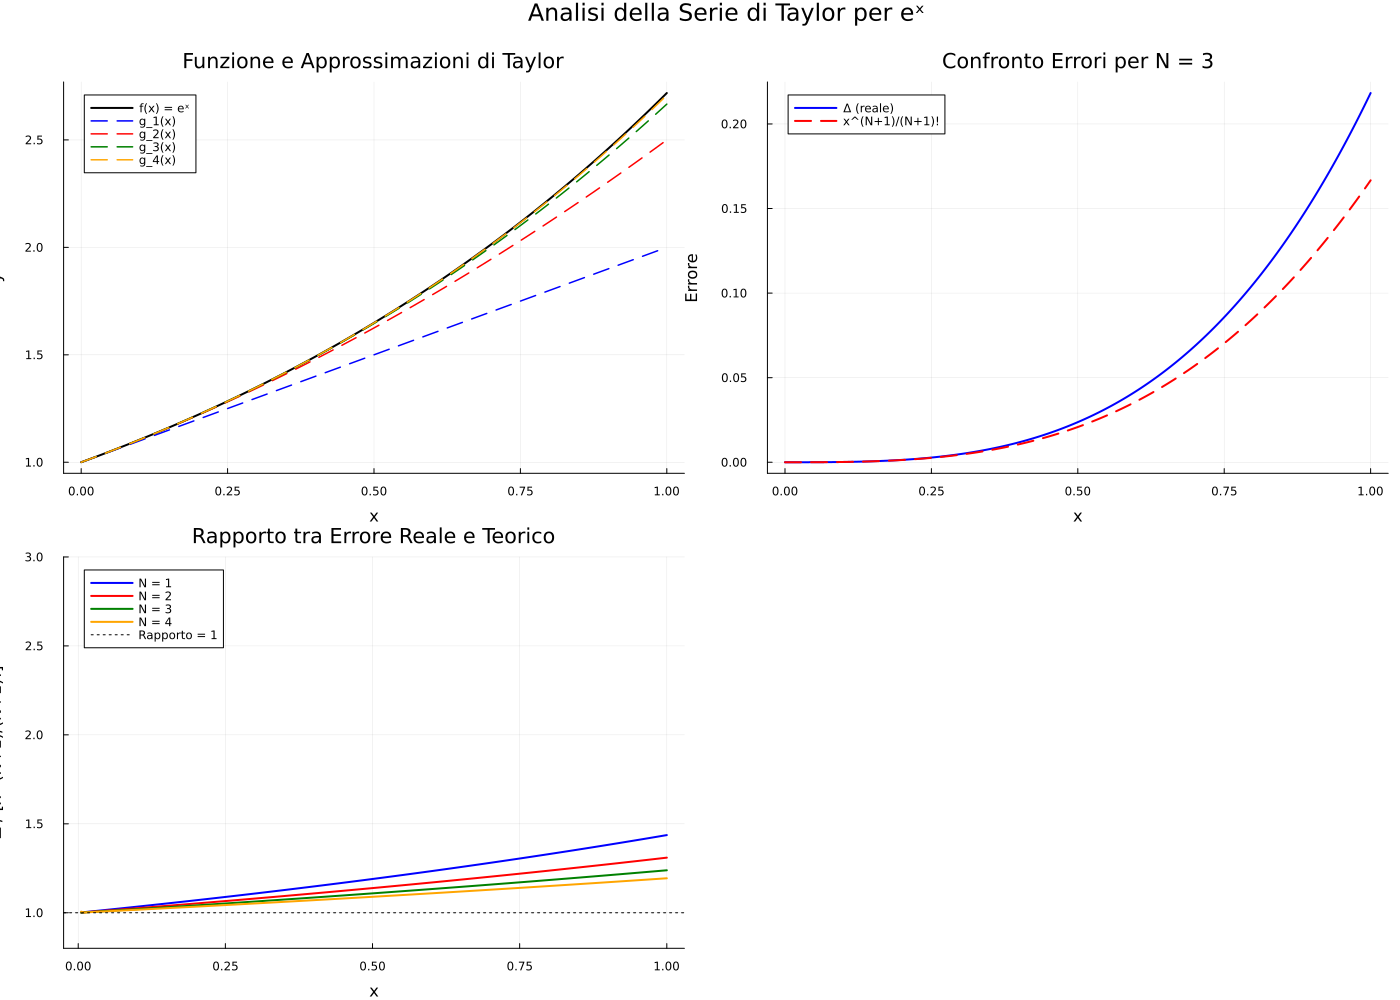

In [120]:
# Combina tutti i grafici
plot(p1, p3, p4, 
     layout=(2, 2), 
     size=(1400, 1000),
     plot_title="Analisi della Serie di Taylor per eˣ")